# 2. R-loop InDelsTopo Analysis

In this notebook, we analyze R-loop sequence libraries using the **Insertion Chain Complex**, implemented in the package **InDelsTopo**. We work with the preprocessed R-loop data generated in `1_Preprocess_Data.ipynb`.

In the underlying experiments, R-loops form at prescribed starting positions on DNA plasmids with varying topologies: **linearized**, **supercoiled**, or **gyrase-treated supercoiled**. Each plasmid contains sequences of known composition, and high-throughput single-molecule R-loop footprinting (SMRF-seq) identifies the starting locations of R-loops. From these data, we extract short DNA subsequences (k-mers) surrounding the R-loop start sites, generating frequency tables of words at each experimental condition.

The input data analyzed here consists of **libraries of k-mers with normalized frequencies**, representing the distribution of DNA words at R-loop starting points. Only the top $N=500$ words per experiment are retained, ensuring robust statistical representation.

### Conclusion

These results provide strong evidence that **DNA topology influences the sequence composition at R-loop starting points**. In particular, the **topological signatures derived from Insertion Chain Complexes** (Euler Characteristic curves and persistent diagrams) can distinguish linearized plasmids from coiled and supercoiled plasmids, reflecting the structural constraints imposed by DNA topology.


In [1]:
import pickle
import os

import numpy as np
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import linkage, dendrogram
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics.pairwise import cosine_distances

from InDelsTopo import Filtration
from persim import plot_diagrams, bottleneck

from utils.utils import plot_euler_curves, plot_tsne, plot_dendrogram, get_color


In [2]:
#Load preprocessed libraries
# --------------------------

# Path to the saved pickle file
pickle_file = 'data/preprocessed/R_loops_14-mers_starting_site_min_len_1_start.pickle'

# Load the libraries
with open(pickle_file, 'rb') as handle:
    Libraries_start = pickle.load(handle)

# Path to the saved pickle file
pickle_file = 'data/preprocessed/R_loops_14-mers_starting_site_min_len_1_end.pickle'

# Load the libraries
with open(pickle_file, 'rb') as handle:
    Libraries_end = pickle.load(handle)

## A. Computing Filtrations and Topological Signatures

We begin by loading the preprocessed R-loop libraries from:  
`data/preprocessed/R_loops_14-mers_starting_site.pickle`.

For each experiment, we construct a **Filtration of Insertion Chain Complexes** using the `Filtration` object from **InDelsTopo**. The normalized word frequencies are used as weights for the words. 

As a topological signature, we compute **Euler Characteristic curves** for each filtration. These curves are sampled over a common set of x-coordinates (`xx = np.arange(0,1,0.01)`) and capture the topological structure of the DNA word collections.

In [3]:
# Compute filtrations and Euler curves
# --------------------------

#Common x-coordinates for Euler Characteristic curves
xx=np.arange(0,1,0.01)

#Compute them
exp_names=[]
filtrations_start=[]
filtrations_end=[]
euler_curves_start=[]
euler_curves_end=[]

for lib_start,lib_end in zip(Libraries_start,Libraries_end):
    exp_name = lib_start['exp_name']
    exp_names.append(exp_name)
    
    #K start
    Table = lib_start['table']
    Words, Freqs = Table['Words'], Table['Freqs']

    K_start = Filtration()
    K_start.compute_d_skeleton(Words, Freqs)

    #K end
    Table = lib_end['table']
    Words, Freqs = Table['Words'], Table['Freqs']

    K_end = Filtration()
    K_end.compute_d_skeleton(Words, Freqs)

    euler_curve_start=K_start.get_euler_curve(xx)
    euler_curve_end=K_end.get_euler_curve(xx)

    euler_curves_start.append(K_start.get_euler_curve(xx))
    euler_curves_end.append(K_end.get_euler_curve(xx))
    filtrations_start.append(K_start)
    filtrations_end.append(K_end)

Product symbol set to (concatenation)
Product symbol set to (concatenation)
Product symbol set to (concatenation)
Product symbol set to (concatenation)
Product symbol set to (concatenation)
Product symbol set to (concatenation)
Product symbol set to (concatenation)
Product symbol set to (concatenation)
Product symbol set to (concatenation)
Product symbol set to (concatenation)
Product symbol set to (concatenation)
Product symbol set to (concatenation)


## B. Visualization of Euler Characteristic Curves

The Euler Characteristic curves are visualized. These plots reveal clear differences between DNA topologies.

We project these curves into **2D using t-SNE**, which shows clustering of experiments by DNA topology: there's a clear separation between Linearized experiments and the remaing ones. Experiments are color-coded according to plasmid topology to highlight separation. 


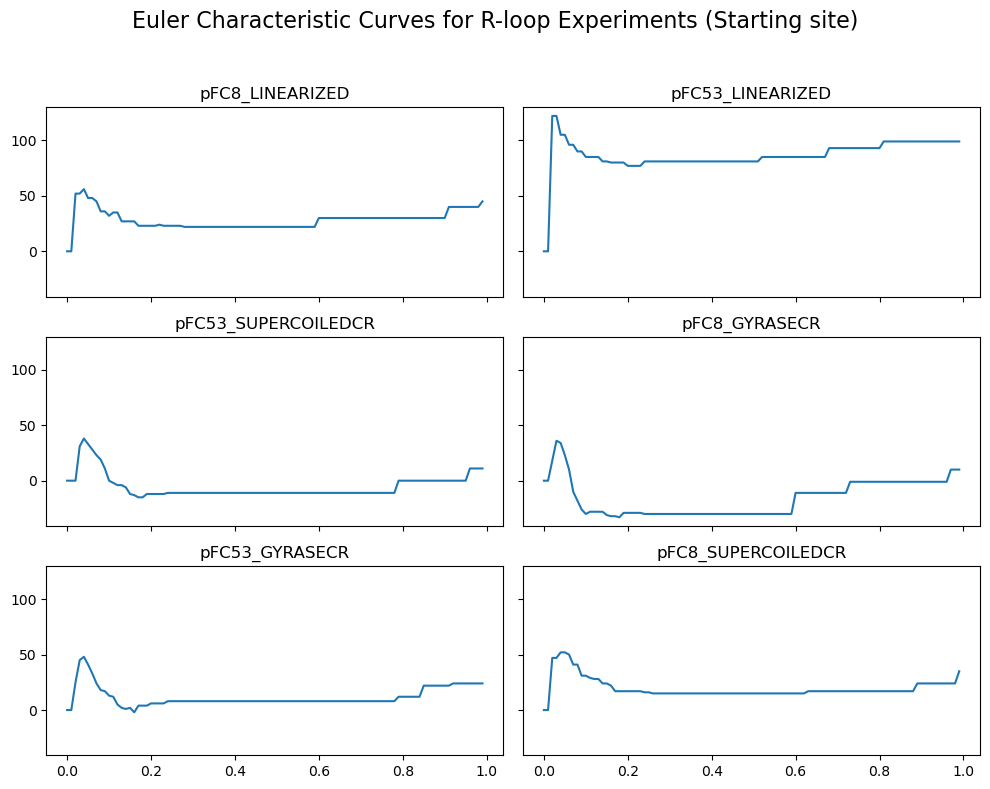

In [4]:
# Plotting Euler Characteristic Curves
# --------------------------
plot_euler_curves(exp_names, euler_curves_start, title="Euler Characteristic Curves for R-loop Experiments (Starting site)")

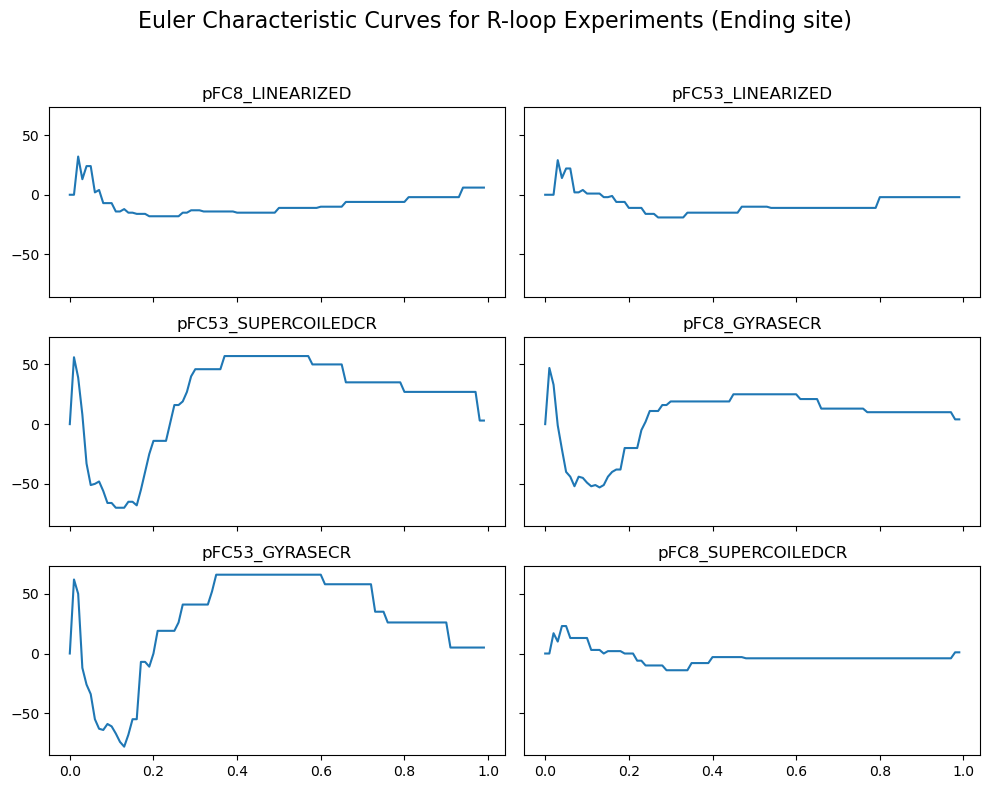

In [5]:
# Plotting Euler Characteristic Curves
# --------------------------
plot_euler_curves(exp_names, euler_curves_end, title="Euler Characteristic Curves for R-loop Experiments (Ending site)")

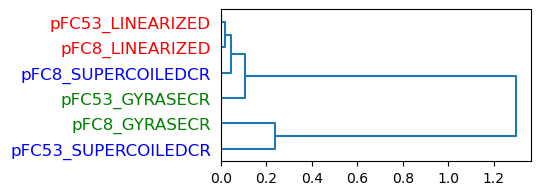

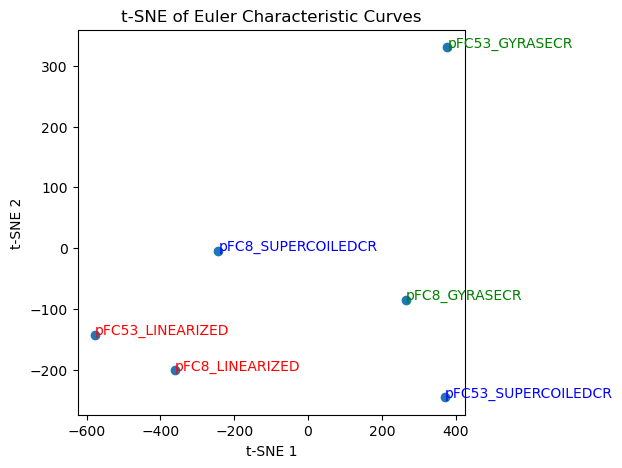

In [6]:
#Clustering of Euler Curves at the start (using cosine distance)
X_start = np.array([curve[1] for curve in euler_curves_start])
agg = AgglomerativeClustering(metric='cosine', linkage='average',compute_distances=True)
agg.fit(X_start)


#To improve interpretability, we swap two branches
agg.children_[4] = agg.children_[4][::-1]
plt.figure(figsize=(4,4))
plot_dendrogram(agg, labels=exp_names)

# Plotting t-SNE projection
# --------------------------
plot_tsne(exp_names, euler_curves_start, title='t-SNE of Euler Characteristic Curves',metric='cosine')

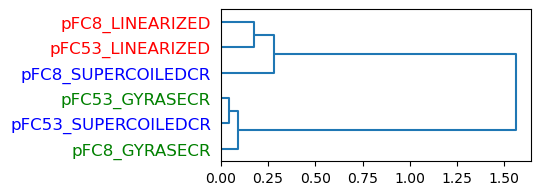

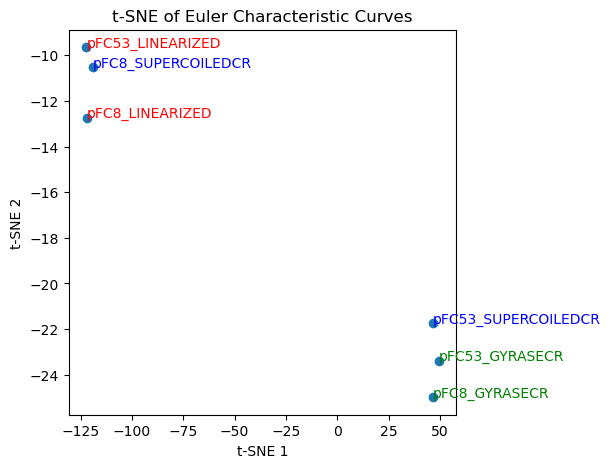

In [7]:
#Clustering of Euler Curves at the end (using cosine distance)
X_end = np.array([curve[1] for curve in euler_curves_end])
agg = AgglomerativeClustering(metric='cosine', linkage='average',compute_distances=True)
agg.fit(X_end)

#To improve interpretability, we swap two branches
agg.children_[2] = agg.children_[2][::-1]
plt.figure(figsize=(4,4))
plot_dendrogram(agg, labels=exp_names)

# Plotting t-SNE projection
# --------------------------
plot_tsne(exp_names, euler_curves_end, title='t-SNE of Euler Characteristic Curves',metric='cosine')

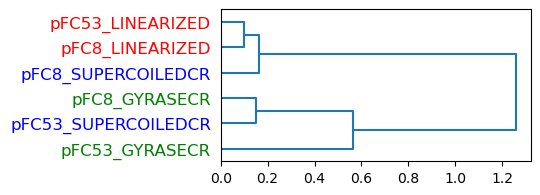

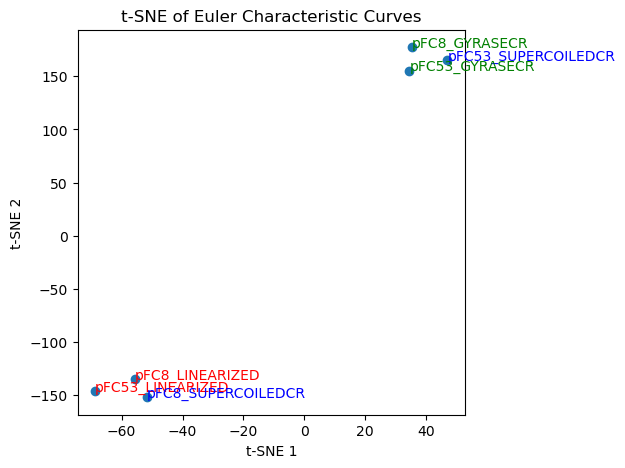

In [8]:
#Clustering using average of cosine distances of Euler Curves at the start and end
D_start = cosine_distances(X_start)
D_end   = cosine_distances(X_end)

D_combined = 0.5 * (D_start + D_end)
agg = AgglomerativeClustering(metric='precomputed',linkage='average',compute_distances=True)
agg.fit(D_combined)

#To improve interpretability, we swap two branches
agg.children_[4] = agg.children_[4][::-1]
plt.figure(figsize=(4,4))
plot_dendrogram(agg, labels=exp_names)


# Plotting t-SNE projection of the concatenated curves
# --------------------------
X_combined = np.concatenate([X_start, X_end], axis=1)
euler_curves_concatenated=[[np.concatenate((curve_start[0], curve_end[0])),
                            np.concatenate((curve_start[1], curve_end[1]))] for 
                           curve_start, curve_end in zip(euler_curves_start, euler_curves_end)]
plot_tsne(exp_names, euler_curves_concatenated, title='t-SNE of Euler Characteristic Curves', metric='cosine')

## C. Persistent Diagrams and Bottleneck Clustering

We extract **persistent homology barcodes** (H0, H1, and H2) for each filtration. Infinite death times are replaced by the finite value 2 to allow computation of **bottleneck distances**.  

Using the pairwise bottleneck distances, we perform **hierarchical clustering**. The resulting dendrogram shows again a clear separation of experiments according to plasmid topology, with the Linearized plasmids forming a separate cluster.  

pFC8_LINEARIZED


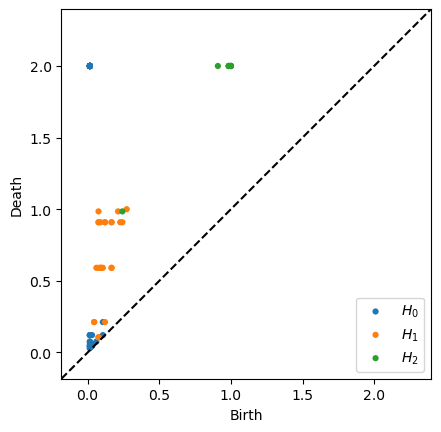

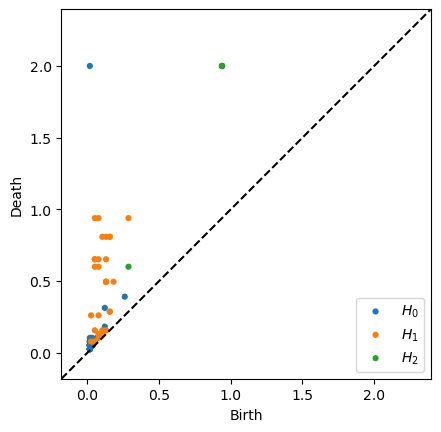

pFC53_LINEARIZED


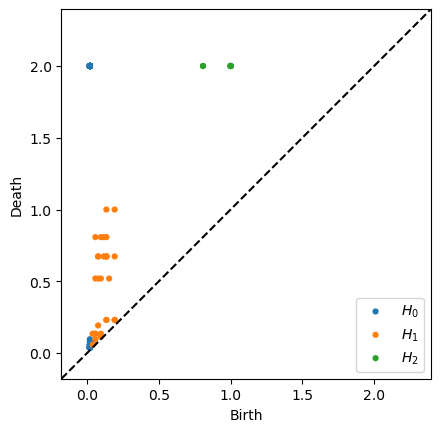

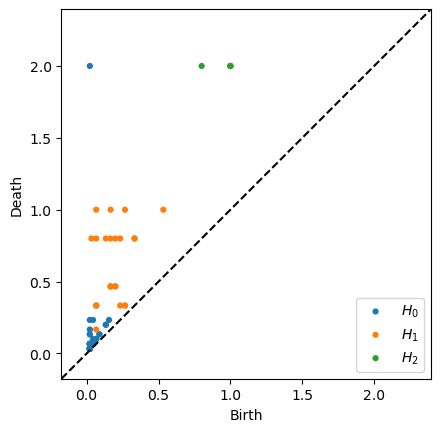

pFC53_SUPERCOILEDCR


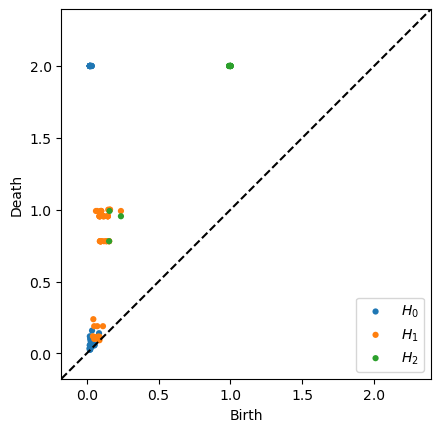

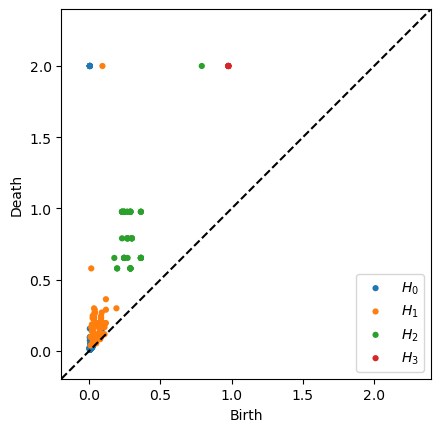

pFC8_GYRASECR


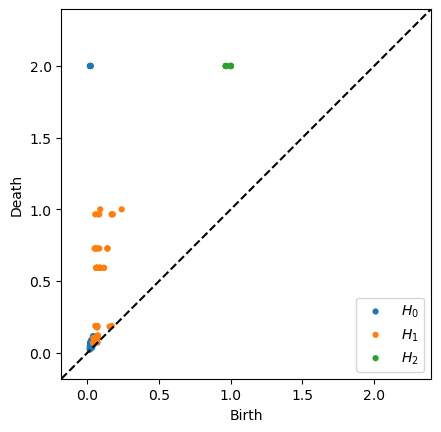

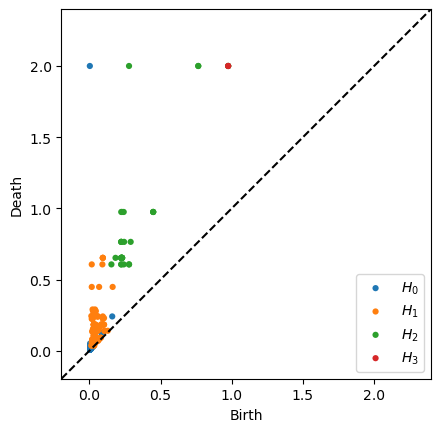

pFC53_GYRASECR


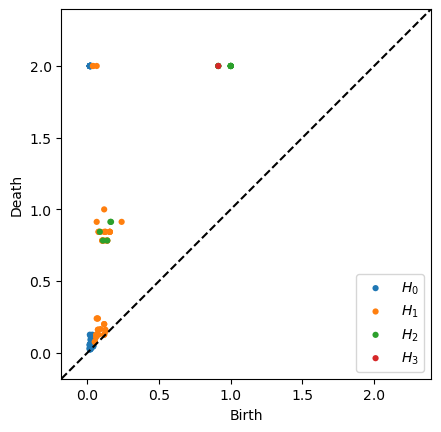

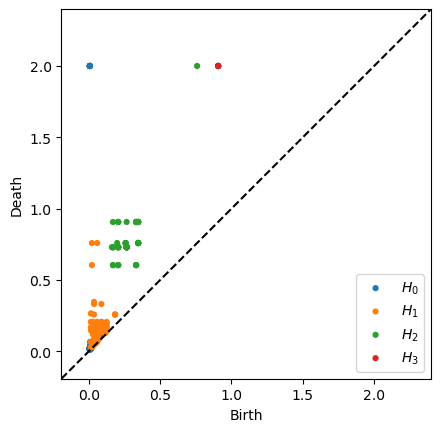

pFC8_SUPERCOILEDCR


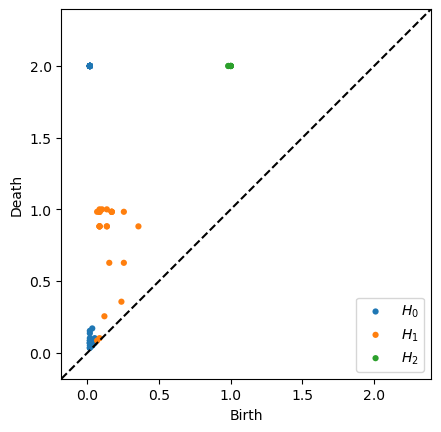

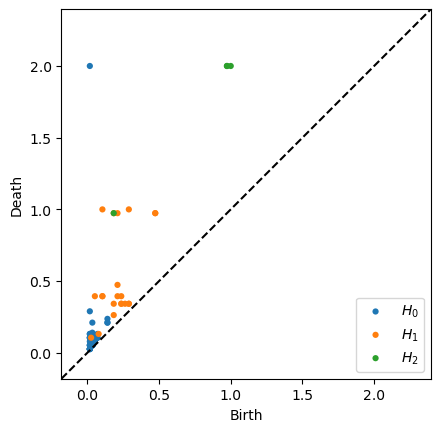

In [9]:
INF_REPLACEMENT=2

# Compute persistence diagrams for all filtrations
# --------------------------
all_dgms_pairs = []

for i, _ in enumerate(filtrations_start):
    K_start=filtrations_start[i]
    K_end=filtrations_end[i]
    
    dgms0_start = K_start.get_persistent_homology_barcodes(inf_value=INF_REPLACEMENT)
    dgms0_end = K_end.get_persistent_homology_barcodes(inf_value=INF_REPLACEMENT)
    
    # Convert to list of numpy arrays
    dgms_start = [np.array(dgms0_start[j]) for j in range(len(dgms0_start))]
    dgms_end = [np.array(dgms0_end[j]) for j in range(len(dgms0_end))]

    # Plot diagrams
    print(exp_names[i])
    plot_diagrams(dgms_start, show=True)
    plot_diagrams(dgms_end, show=True)

    all_dgms_pairs.append([dgms_start, dgms_end])

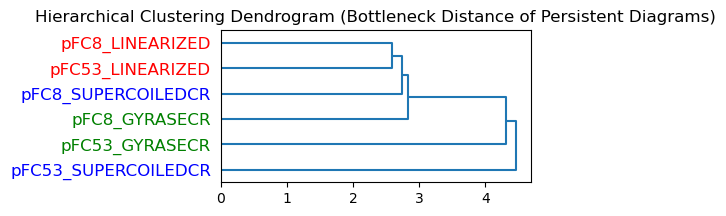

In [10]:
# Compute pairwise bottleneck distances (using H0, H1 and H2 combined)
# --------------------------
num_exp = len(all_dgms_pairs)
distance_matrix = np.zeros((num_exp, num_exp))

for i in range(num_exp):
    dgms1_start=all_dgms_pairs[i][0]
    dgms1_end=all_dgms_pairs[i][1]
    for j in range(i+1, num_exp):
        dgms2_start=all_dgms_pairs[j][0]
        dgms2_end=all_dgms_pairs[j][1]
        
        d0 = bottleneck(dgms1_start[0], dgms2_start[0]) + bottleneck(dgms1_end[0], dgms2_end[0])  # H0
        d1 = bottleneck(dgms1_start[1], dgms2_start[1]) + bottleneck(dgms1_end[1], dgms2_end[1])  # H1
        d2 = bottleneck(dgms1_start[2], dgms2_start[2]) + bottleneck(dgms1_end[2], dgms2_end[2])  # H2
        
        distance = d0 + d1 + d2  # simple sum
        distance_matrix[i, j] = distance
        distance_matrix[j, i] = distance

# Hierarchical clustering
# --------------------------
agg = AgglomerativeClustering(metric='precomputed', linkage='average',compute_distances=True)
agg.fit(distance_matrix)

#To improve interpretability, we swap two branches
agg.children_[0] = agg.children_[0][::-1]

plt.figure(figsize=(4,4))
plt.title("Hierarchical Clustering Dendrogram (Bottleneck Distance of Persistent Diagrams)")
plot_dendrogram(agg, labels=exp_names)